# Notebook for testing the custom DataLoaders

In [1]:
# Imports
import os
import sys
sys.path.append(os.path.abspath(".."))

import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import src.util.datasets as ds

from torch.utils.data import DataLoader
from pathlib import Path

In [2]:
# Load data
data_config_path    = Path("/home/veit-hucke/Projects/tta-flow/data/dataset_configs/retouch_original_spectralis_local.csv")
df                  = ds.load_data_from_csv(data_config_path)
df

,volume,mask
0,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
1,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
2,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
3,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
4,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
5,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
6,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
7,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
8,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...
9,/home/veit-hucke/Data/OCT/retouch/spectralis/0...,/home/veit-hucke/Data/OCT/retouch/annotations/...


### Test Inference Dataset

In [3]:
# Define transforms
transforms  = A.Compose([
    A.Resize(height=128, width=128),
    A.Normalize(mean=0.5, std=0.5, max_pixel_value=1.),
    A.ToTensorV2(),
])

# Define datasets
inference_dataset       = ds.FlowMatchingInferenceDataset(dataframe=df, transform=transforms)
inference_dataloader    = DataLoader(dataset=inference_dataset, batch_size=1, shuffle=False)

Loading inference data.


Loading volumes: 100%|██████████| 24/24 [00:00<00:00, 65.99it/s]

INFO: Loaded 24 volumes


In [4]:
# Manually iterate through dataset
for i, sample in enumerate(inference_dataset):
    print(f"Sample {i}: Shape {sample.shape}, dtype {sample.dtype}, minmax: ({sample.min():.2f}, {sample.max():.2f}), device: {sample.device}")
    if i == 4:
        break

Sample 0: Shape (49, 128, 128), dtype float32, minmax: (-1.00, 1.00), device: cpu
Sample 1: Shape (49, 128, 128), dtype float32, minmax: (-1.00, 1.00), device: cpu
Sample 2: Shape (49, 128, 128), dtype float32, minmax: (-1.00, 1.00), device: cpu
Sample 3: Shape (49, 128, 128), dtype float32, minmax: (-1.00, 1.00), device: cpu
Sample 4: Shape (49, 128, 128), dtype float32, minmax: (-1.00, 1.00), device: cpu


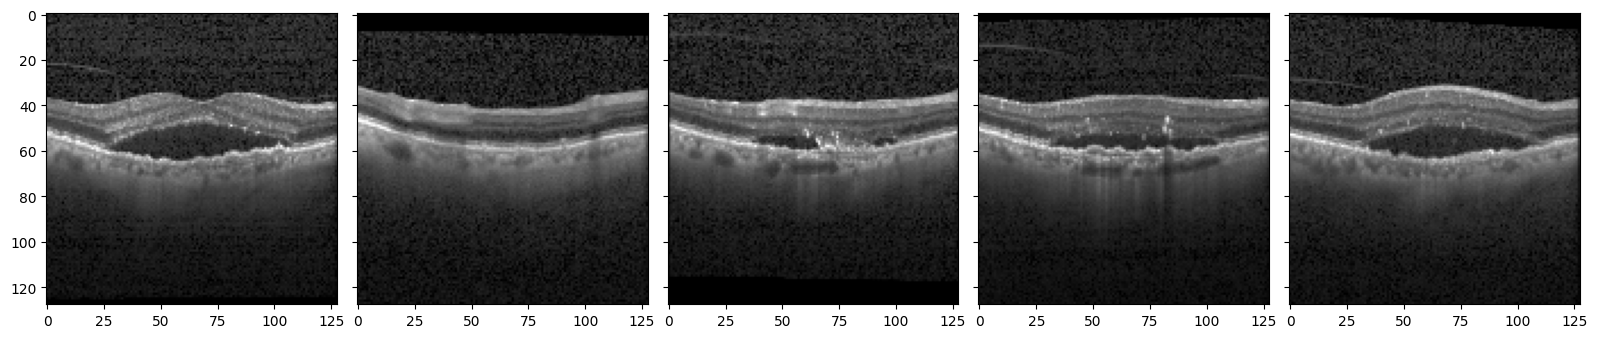

In [5]:
# Show some slices
X           = next(iter(inference_dataset))
_d, _, _    = X.shape
idxs        = np.random.choice(_d, 5)

# Plot
fig, axes = plt.subplots(1, 5, sharex=1, sharey=1, figsize=(16, 9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[idxs[i]], cmap="grey")
plt.tight_layout()
plt.show()

In [6]:
# Qick test DataLoader
for j in range(5):
    batch   = next(iter(inference_dataloader))
    print(f"Sample {j}: Shape {batch.shape}, dtype {batch.dtype}, minmax: ({batch.min():.2f}, {batch.max():.2f}), device: {batch.device}")

Sample 0: Shape torch.Size([1, 49, 128, 128]), dtype torch.float32, minmax: (-1.00, 1.00), device: cpu
Sample 1: Shape torch.Size([1, 49, 128, 128]), dtype torch.float32, minmax: (-1.00, 1.00), device: cpu
Sample 2: Shape torch.Size([1, 49, 128, 128]), dtype torch.float32, minmax: (-1.00, 1.00), device: cpu
Sample 3: Shape torch.Size([1, 49, 128, 128]), dtype torch.float32, minmax: (-1.00, 1.00), device: cpu
Sample 4: Shape torch.Size([1, 49, 128, 128]), dtype torch.float32, minmax: (-1.00, 1.00), device: cpu


Data shape: (128, 128, 128)


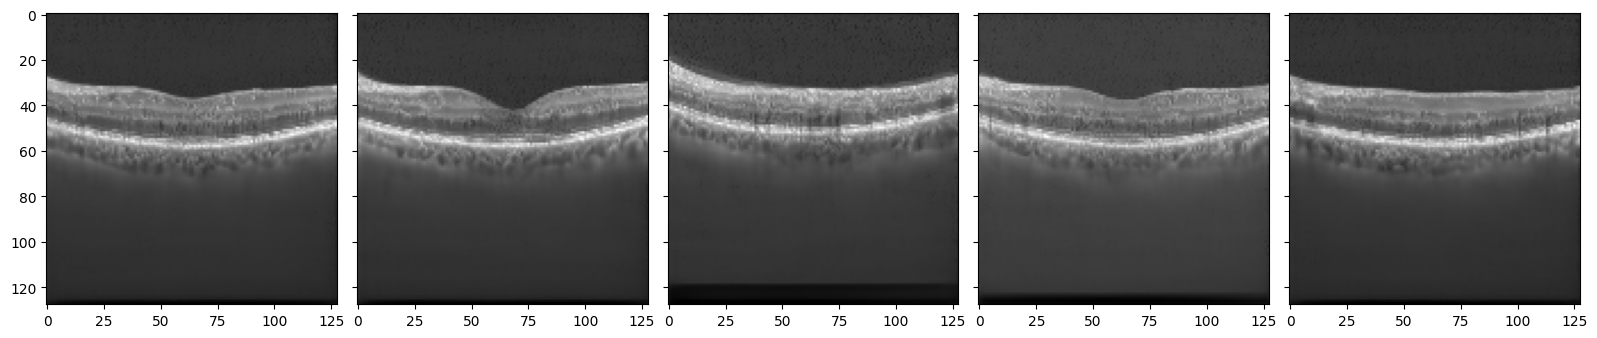

In [7]:
# Show some slices
X           = np.load("/home/veit-hucke/Projects/tta-flow/runs/2026-03-05_11-47-31-spectralis_128_test/inference/outputs/pred_002.npy")
_d, _, _    = X.shape
idxs        = np.random.choice(_d, 5)
print(f"Data shape: {X.shape}")

# Plot
fig, axes = plt.subplots(1, 5, sharex=1, sharey=1, figsize=(16, 9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[idxs[i]], cmap="grey")
plt.tight_layout()
plt.show()

### Test Train Dataset

In [8]:
# Define transforms
transforms_train  = A.Compose([
    A.Resize(height=128, width=128),
    A.Normalize(mean=0.5, std=0.5, max_pixel_value=1.),
    A.HorizontalFlip(p=0.5),
    A.ToTensorV2(),
])

# Define datasets
train_dataset       = ds.FlowMatchingTrainDataset(dataframe=df, transform=transforms_train)
train_dataloader    = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Loading target data.


Loading files: 100%|██████████| 24/24 [00:01<00:00, 21.67it/s]

INFO: Loaded 1176 target images


In [10]:
X0, X1 = next(iter(train_dataset))
X0.shape

torch.Size([1, 128, 128])

In [15]:
X0, X1 = next(iter(train_dataloader))
X0.shape, X1.shape

(torch.Size([8, 1, 128, 128]), torch.Size([8, 1, 128, 128]))

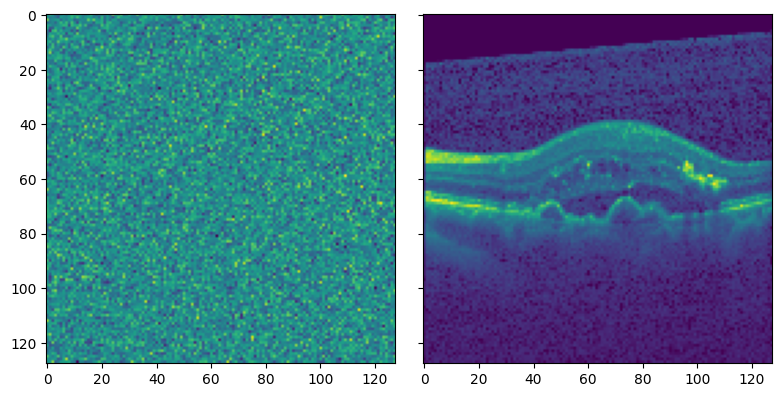

In [20]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, sharex=1, sharey=1, figsize=(8, 4.5))
ax0.imshow(X0[3, 0])
ax1.imshow(X1[3, 0])
plt.tight_layout()
plt.show()